# **SPECTRA v2**

In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from torch_geometric.utils import from_networkx
import os
from tqdm import tqdm
from scipy import sparse
import anndata as ad

import warnings
warnings.filterwarnings("ignore")

# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


12.1
Tesla V100-SXM2-32GB
cuda


In [2]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/michele.calabro/.netrc.
wandb: Currently logged in as: michi-geco97 (michi-geco97-politecn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

**NOTE:** put `add_control=True` to **concatenate** to the generated, syntetic dataset `pred_adata` the **ground truth control cells**. Why? Because we need them to calculate DEGs 

### **Data import**
**filtering and normalization**: quite standard, we remove perturbations with less than 100 samples (can be changed)

In [3]:
# data loading and filtering
#adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad') #VCC
adata = sc.read_h5ad('data/K562_gwps_raw_singlecell_01.h5ad') # replogle
adata

AnnData object with n_obs × n_vars = 1989578 × 8248
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'

In [4]:
adata.var['gene_name'] = adata.var['gene_name'].astype('string')
adata.var_names = adata.var['gene_name']
adata.var_names_make_unique()

In [5]:
from utils import data_preprocessing

adata = data_preprocessing(adata, 'gene', 'non-targeting', logtransform=True, min_cells_per_pert=100)
adata

View of AnnData object with n_obs × n_vars = 1869462 × 8248
    obs: 'gem_group', 'target_gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells'
    uns: 'log1p'

In [6]:
gene_list = pd.read_csv('/scratch/michele.calabro/gears/VCC/SPECTRA/data/replogle_2022_5k_genes_mapped.csv')
gene_list = gene_list['gene_name']
gene_list = gene_list.tolist()
mask = adata.var_names.isin(gene_list)
adata = adata[:, mask]
adata

View of AnnData object with n_obs × n_vars = 1869462 × 4999
    obs: 'gem_group', 'target_gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells'
    uns: 'log1p'

In [7]:
import pickle

with open("scGPT_embeddings_all_genes.pkl", "rb") as f:
    scgpt_dict = pickle.load(f)

### **GRN preparation**

***
### Patrick stuff

In [25]:
# patrick guanlab (stock)
A = np.load('Patrick_networks/Hierarchist_14_adjacency.npz') #guanlab_stock_3.5k_directed.npz
adjacency = A['adjacency']
gene_names = A['gene_names']

# Create weighted DiGraph (parallel_edges=False treats values as weights)
G = nx.from_numpy_array(
    adjacency,
    parallel_edges=False,
    create_using=nx.DiGraph(),
    edge_attr='weight',  # Attribute name for weights
)

# Relabel nodes with gene names (must be same length as matrix dims)
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
#G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if np.log(d['weight']+1) < 10])


num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filter adata
gene_list = list(G.nodes())
mask = adata.var_names.isin(gene_list)
adata = adata[:, mask]
adata

Number of nodes: 3342
Number of edges: 12564
Number of node features per node: 1


View of AnnData object with n_obs × n_vars = 219999 × 3342
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### End of patrick stuff
***

### Replogle SCENIC grn

In [ ]:
# network file
with open('../SCENIC_GRNs/SCENIC_GRNs/networks/repogle_network.json', 'r') as json_file:
    network = json.load(json_file)
    
# Create the networkx graph
G = nx.DiGraph()
for tf, targets in network.items():
    for target, weight in targets:
        G.add_edge(tf, target, weight=weight)

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filtering data to gene contained in the network G
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :].copy()
adata

***

### GRNBoost2 VCC network on 3406 genes

In [8]:
# load GRN
network_data = pd.read_csv('../SCENIC_GRNs/SCENIC_GRNs/temp_results/replogle_adjacencies_vcc.tsv', sep='\t')

# Create the networkx graph
G = nx.DiGraph()
for i in range(network_data.shape[0]):
    edge = network_data.iloc[i,:]
    if np.abs(edge['importance'])>0.1: #TODO: dumb pruning, make somehting better please
        G.add_edge(edge['TF'], edge['target'], weight=edge['importance'])

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
gene_list = list(G.nodes)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

Number of nodes: 4903
Number of edges: 132007
Number of node features per node: 1


In [9]:
# filtering data to gene contained in the network G
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :]
adata

View of AnnData object with n_obs × n_vars = 917355 × 4903
    obs: 'gem_group', 'target_gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'n_genes'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells'
    uns: 'log1p'

***

**Once loaded the network file**, check compatibility with the dataset variables and relabel the nodes

In [10]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}

edges = [(gene_to_idx[u], gene_to_idx[v]) for u, v in G.edges()] #this forces edge_index to match the order of adata.var_names
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# G = nx.relabel_nodes(G, gene_to_idx)
# edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

Hyperparameters and wandb setup:

In [11]:
# here we put all the hyperparameters, metadata and stuff
config = dict(
    dataset_size=adata.shape[0],#(adata.obs['target_gene'] != 'non-targeting').sum(),
    test_ratio=0.2,
    val_ratio=0.1,
    batch_size=24,
    n_channels=32,
    dropout_p=0.1,
    num_node_features=1,
    lr=0.001,
    n_epochs=20,
    alpha = 4.,
    beta = 0.01,
    dataset="replogle",
    architecture="FAGCN")

In [12]:
# map genes to gene names for scGPT
scgpt_dict = {gene_to_idx[k]: v for k, v in scgpt_dict.items() if k in gene_to_idx}

# embedding lookup table
scgpt_dim = len(next(iter(scgpt_dict.values())))
embedding_matrix = torch.zeros((num_nodes, scgpt_dim))
for gene_id, emb in scgpt_dict.items():
    embedding_matrix[gene_id] = torch.tensor(emb, dtype=torch.float32)


### **Dataloaders preparation**
Compared with the original SPECTRA model, here we should calculate the dataloaders so that in each batch there are only samples taken from the same perturbations.

**NOTE**: currently the split is random cell-wise, if we want to esclude some perturbations, I think it's enough to sort the dataset by column `target_gene`

In [13]:
from utils import build_model_dataloaders_split_perturbs

train_loader, val_loader, test_loader, train_size, test_size, _, train_adata, _, test_adata = build_model_dataloaders_split_perturbs(adata, edge_index, config)

Total Unique Perturbations: 3770
Train set: 2639 perts | 588396 cells
Val set: 377 perts | 84896 cells
Test set: 754 perts | 168735 cells


Weights based on (gorund-truth) DEGs:

In [14]:
#NOTE: new DEGs weights
from WMSE import compute_weights

gene_weights = compute_weights(train_adata, gene_to_idx, cells_per_pert=256)

In [ ]:
# save genee weights


### **Model setup**

In [ ]:
wandb.init(
    project="SPECTRA_replogle",       # The name of your project in wandb
    name=config['architecture'],   # (Optional) Name of this specific run
    config=config               # Pass your dictionary here!
)

In [ ]:
from spectra_v2_fagcn import PerturbModel

model = PerturbModel(
    edge_index, 
    num_nodes, 
    device, 
    config = config,
    gene_embeddings = embedding_matrix,
    gene_weights=gene_weights
)
model = model.to(device)
print(model)

number of trainable parameters: 236993
PerturbModel(
  (gene_embeddings): Embedding(3342, 512)
  (project_gene): Linear(in_features=512, out_features=32, bias=True)
  (project_expr): Linear(in_features=1, out_features=32, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=32, bias=True)
    (shift): Linear(in_features=1, out_features=32, bias=True)
  )
  (add_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (ko_mu): Embedding(3342, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=32, bias=True)
      (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=32, out_features=32, bias=True)
      (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (

In [ ]:
idx_to_gene = {v: k for k, v in gene_to_idx.items()}

In [ ]:
from spectra_v2_fagcn import train
_, _, test_wmse = train(model=model, 
    train_loader=train_loader, 
    test_loader=val_loader,
    lr=config['lr'], 
    n_epochs=config['n_epochs'],  
    device=device,
    wandb_support=True,
    var_names = adata.var_names.tolist(),
    idx_to_gene = idx_to_gene,
    alpha_weight=config['alpha'],   # Injected from Sweep
    beta_weight=config['beta'],     # Injected from Sweep
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/michele.calabro/.netrc.
wandb: Currently logged in as: michi-geco97 (michi-geco97-politecn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


training at epoch 1: 100%|██████████| 5802/5802 [06:08<00:00, 15.74it/s]


training KL = 0.54586 | mse = 0.120 | cos = 0.956


testing with MMD...: 100%|██████████| 526/526 [00:14<00:00, 36.47it/s]


Validation metric improved to 2.6481. Saving best model...


...

testing with MMD...: 100%|██████████| 526/526 [00:13<00:00, 37.86it/s]


No improvement. Patience: 5/5
Early stopping triggered! No improvement for 5 epochs.

--- Training concluded. Initiating Final Evaluation ---
Reloading best epoch weights for final evaluation...


100%|██████████| 13/13 [04:16<00:00, 19.74s/it]
wandb: ERROR The nbformat package was not found. It is required to save notebook history.



--- Summary ---
Average Baseline AUPRC: 0.0466
Average Model AUPRC:    0.0903
FINAL TEST METRIC: 0.0903


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
train/cosine_loss,█▇▄▂▁▁▁▁▁▁▁▁▁
train/global_loss,█▄▂▂▁▁▁▁▁▁▁▁▁
train/kl_divergence,▁▂▅████▇▇▇▇▇▇
train/mmd_ctrl,▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mmd_pert,█▂▂▂▁▁▁▁▁▁▁▁▁
train/mse,█▄▂▁▁▁▁▁▁▁▁▁▁
val/AUPRC,▁
val/test_MMD,█▂▁▁▁▁▁▁▁▁▁▁▁
epoch,13
train/cosine_loss,0.82901


In [ ]:
sweep_config = {
	'method': 'random',
	'parameters': {
		'dropout': {
			'values': [0.1, 0.15, 0.2, 0.25]
			},
		'learning rate':{
			'distribution':'uniform',
			'min':0,
			'max':0.1
			},
		'layer_size': {
			'distribution': 'q_log_uniform_values',
			'q': 8,
			'min': 8,
			'max': 64,
			}
	}
	'metric' = {
		'name':'val/AUPRC'
		'goal':'maximize'
	}
	'early_terminate' = {
		'type': 'hyperband',
		'min_iter': 3,   # Don't kill any runs before epoch 3 (gives them a chance to warm up)
		'eta': 3,        # The standard strictness bracket for Hyperband'
	}
}

In [ ]:
sweep_id = wandb.sweep(sweep_config, project="SPECTRA")

In [ ]:
method: bayes # or random
metric:
  name: val/epoch_metric
  goal: maximize
# Add this block:
early_terminate:
  type: hyperband
  min_iter: 3   # Don't kill any runs before epoch 3 (gives them a chance to warm up)
  eta: 3        # The standard strictness bracket for Hyperband
parameters:
  # ... your hyperparams here ...

In [16]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train/cosine_loss,█▇▅▄▃▂▂▁▁▁▁▁▁▁▁
train/global_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁
train/kl_divergence,▁▂▂▃▅▇██████▇▇█
train/mmd_ctrl,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mmd_pert,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/mse,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁
val/AUPRC,▁
val/test_MMD,█▄▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,15
train/cosine_loss,0.77338


In [14]:
torch.save(model.state_dict(), "test_DirGNN_Cheb_fungi.pth")

***

# **Testing**

In [15]:
model.load_state_dict(torch.load("weights/best_model_weights_FAGCN_bigbatches.pth"))

<All keys matched successfully>

In [16]:
model.eval()

PerturbModel(
  (gene_embeddings): Embedding(3342, 512)
  (project_gene): Linear(in_features=512, out_features=32, bias=True)
  (project_expr): Linear(in_features=1, out_features=32, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=32, bias=True)
    (shift): Linear(in_features=1, out_features=32, bias=True)
  )
  (add_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (ko_mu): Embedding(3342, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=32, bias=True)
      (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=32, out_features=32, bias=True)
      (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (proj_mu): Linear(in_features=32, out_fe

Build the test adata `real_adata`- last n rows of the entire dataset (NOTE: adjust if needed)

In [18]:
n_cells = test_size
real_adata = adata[-n_cells:, :]
n_min_samples = 200

counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]
gene_counts_dict = counts.drop('non-targeting').to_dict() # creation of dict: for each pertuyrbation how many cells to generate
real_adata = real_adata[real_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 18658 × 3342
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [17]:
# for perturbation split
real_adata = test_adata
n_min_samples = 50
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]
gene_counts_dict = counts.drop('non-targeting').to_dict() # creation of dict: for each pertuyrbation how many cells to generate
real_adata = real_adata[real_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 36293 × 3342
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'

The dictionary `gene_count_dict` contains, for each perturbation, **the number of cells we want the model to generate with that perturbation**. Above, we have set the abundance of cells for each perturbation to be the same as in `real adata`.

This dictionary is the **main input** to be passed to spectra in order to generate a synthetic Perturb-seq dataset, as show in the next cell:

**NOTE:** put `add_control=True` to **concatenate** to the generated, syntetic dataset `pred_adata` the **ground truth control cells**. Why? Because we need them to calculate DEGs 

In [18]:
from utils import generate_adata_from_control

pred_adata = generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, real_adata.var_names, add_control=True)
pred_adata

100%|██████████| 27/27 [00:28<00:00,  1.05s/it]


AnnData object with n_obs × n_vars = 36293 × 3342
    obs: 'target_gene'

# **Benchmark and evaluation metrics**

First thing first, a **baseline** is needed:
* for each perturbation *already seen* during training, we return the average gene expression of all the samples in the training data (`adata[:train_size,:]`) with that perturbation label
* for perturbations *NOT seen* suring training, we return the average of the average of gene expressions for all perturbations (very naive baseline but it's very popular in most benchmark)

In [19]:
from utils import generate_adata_baseline

pred_adata_2 = generate_adata_baseline(gene_counts_dict, train_adata, real_adata.var_names) #adata[:train_size,:]

# Append the non-targeting controls to the example anndata if they're missing
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata_2.obs["target_gene"].unique():
    assert np.all(pred_adata_2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata_2 = ad.concat(
        [
            pred_adata_2,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata_2

100%|██████████| 27/27 [00:00<00:00, 409.19it/s]


AnnData object with n_obs × n_vars = 36293 × 3342
    obs: 'target_gene'

In [20]:
real_adata.write('results/real_adata.h5ad')
pred_adata.write('results/pred_adata-FAGCN_FiLM.h5ad')
pred_adata_2.write('results/pred_adata-baseline.h5ad')

#### Old metrics:

In [21]:
from benchmark import process_datasets

process_datasets('results/real_adata.h5ad', ['results/pred_adata-baseline.h5ad', 'results/pred_adata-FAGCN_FiLM.h5ad'],
                    ['mae', 'mse', 'pcc_delta', 'f1', 'auprc', 'common_degs'])

[*] Loading real dataset from: results/real_adata.h5ad
[*] Loading prediction for model 'baseline': pred_adata-baseline.h5ad
    -> Calculating mae...
    -> Calculating mse...


    -> Calculating pcc_delta...


    -> Calculating f1...


100%|██████████| 27/27 [01:48<00:00,  4.03s/it]


    -> Calculating auprc...


...

100%|██████████| 27/27 [01:47<00:00,  3.98s/it]


    -> Calculating auprc...


100%|██████████| 27/27 [02:30<00:00,  5.58s/it]



--- Summary ---
Average Baseline AUPRC: 0.0968
Average Model AUPRC:    0.1023
    -> Calculating common_degs...


{'mae': {'baseline': {'AKT2': np.float32(0.014297858),
   'SHPRH': np.float32(0.013640152),
   'CAMSAP2': np.float32(0.008258294),
   'TWF2': np.float32(0.008545577),
   'SAFB': np.float32(0.02179367),
   'TSC22D4': np.float32(0.008192317),
   'MAP3K7': np.float32(0.009627602),
   'STAG2': np.float32(0.036596123),
   'USP22': np.float32(0.01429374),
   'CAST': np.float32(0.012816819),
   'CASP3': np.float32(0.032430112),
   'MED13L': np.float32(0.011886719),
   'SNCA': np.float32(0.013362049),
   'TMBIM6': np.float32(0.010042169),
   'SDC1': np.float32(0.018127203),
   'CENPO': np.float32(0.008484786),
   'CLDN7': np.float32(0.011447729),
   'NDUFB4': np.float32(0.013567678),
   'KDM1A': np.float32(0.08735583),
   'TRAPPC6A': np.float32(0.022331996),
   'MED24': np.float32(0.043174986),
   'PRR12': np.float32(0.017667677),
   'MED1': np.float32(0.029097168),
   'METTL3': np.float32(0.07811351),
   'OXCT1': np.float32(0.021212133),
   'SEC62': np.float32(0.034389947),
   'ATM': np.float

In [18]:
from val_scores import *

score = calc_mae(real_adata, pred_adata)
print(f"Average: {sum(score.values())/len(score):.4f}")

Average: 0.0253


In [48]:
score = calc_corr(real_adata, pred_adata)
print(f"Average: {sum(score.values())/len(score):.4f}")

Average: 0.9922


#### AUPRC score: the ultimate DEGs evaluation metric

In [ ]:
from val_scores import *
from visualization import eval_barplot

#model_results, baseline_results = calc_auprc(real_adata, pred_adata)
model_results = calc_mse(real_adata, pred_adata, n_top_degs=50)
eval_barplot(model_results, 'mse')

This is my custom and robus F1 classification score, still useful.

100%|██████████| 112/112 [01:35<00:00,  1.17it/s]


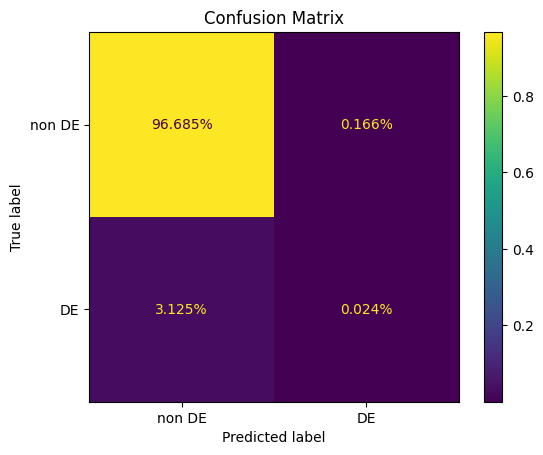

array([[9.66846846e-01, 1.66198306e-03],
       [3.12526214e-02, 2.38549618e-04]])

In [38]:
from val_scores import RobustDES

des_calculator = RobustDES(lfc_threshold=0.3, alpha=0.01)
des_calculator.DES_confusion_matrix(perts,real_adata,pred_adata,'target_gene', 'non-targeting')

### Benchmark new
taken from paper [Benchmarking algorithms for generalizable single-cell perturbation response prediction](https://www.nature.com/articles/s41592-025-02980-0)

***

### **Additional stuff**

In [ ]:
pred_adata.write('results/pred_adata.h5ad')
real_adata.write('results/real_adata.h5ad')

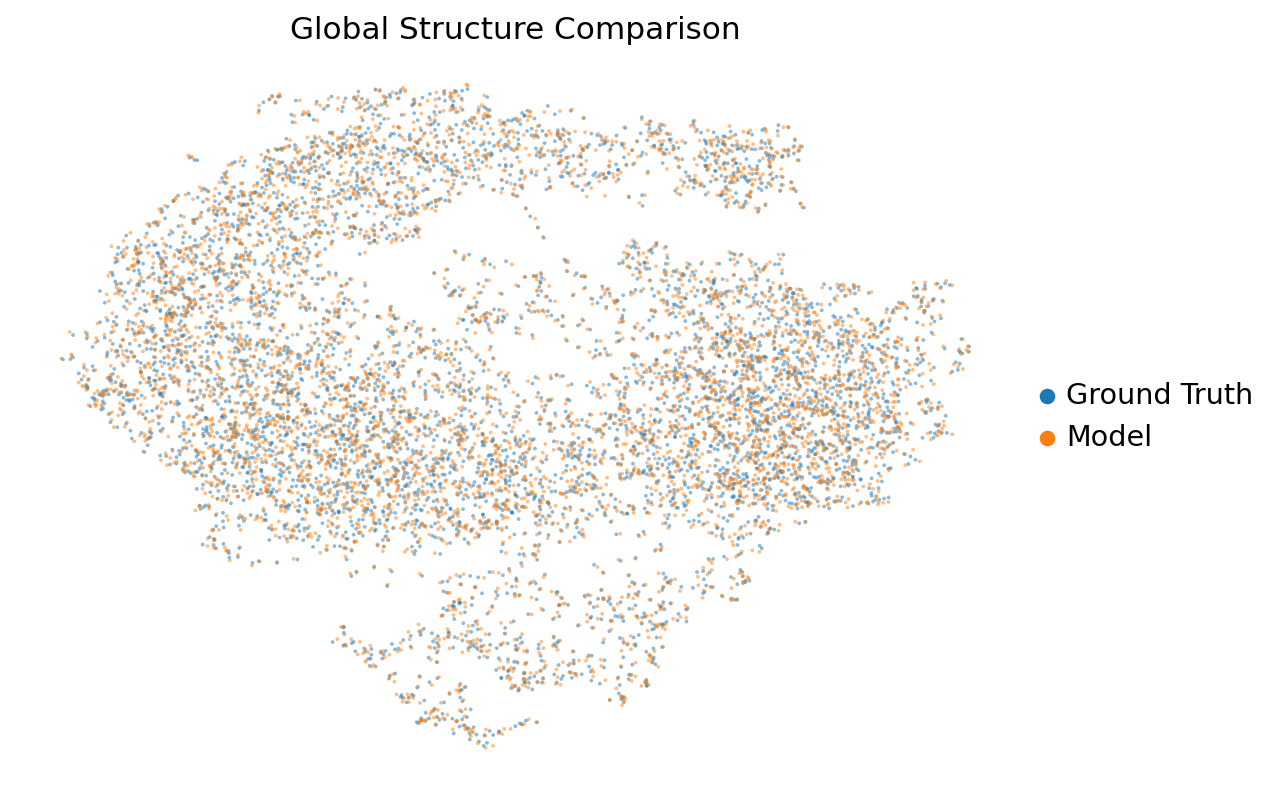

In [79]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Label your datasets
real_adata.obs['dataset'] = 'Ground Truth'
pred_adata.obs['dataset'] = 'Model'

# 2. Concatenate them
adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
    pred_adata[pred_adata.obs['target_gene']=='non-targeting'],
    batch_key='source',
    index_unique='-'
)

# 3. Compute embeddings
sc.pp.pca(adata_combined)
sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined)   # <-- FIXED

# 4. Plot
sc.set_figure_params(figsize=(8, 6))
sc.pl.umap(
    adata_combined,
    color=['dataset'],
    alpha=0.5,
    title="Global Structure Comparison",
    frameon = False,
    #save = "umap.pdf"
)


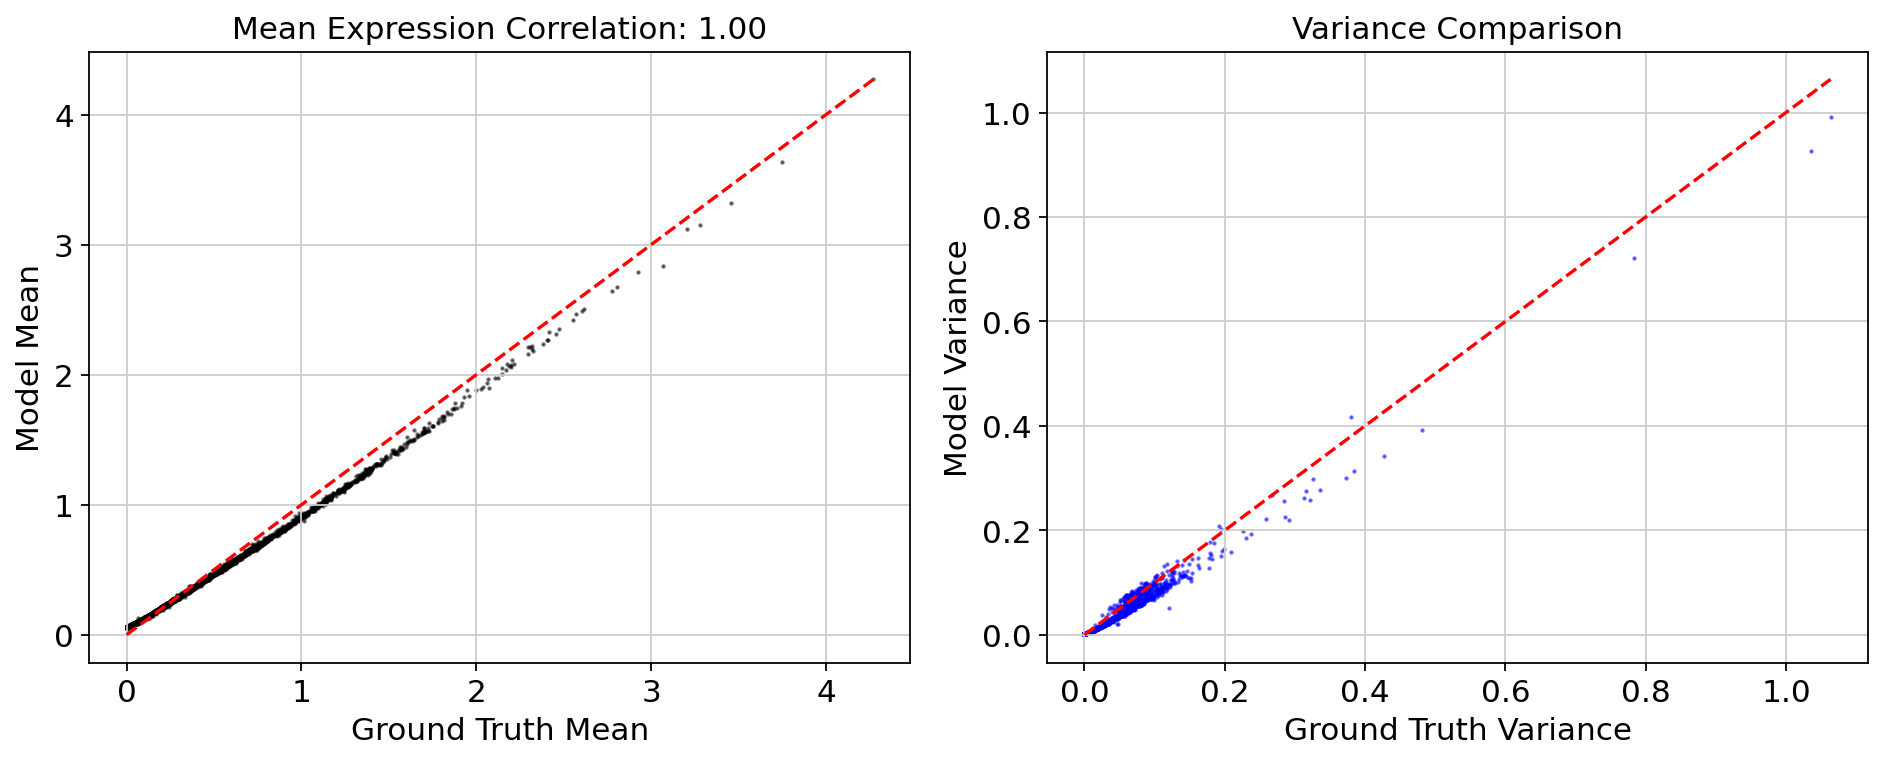

In [ ]:
import numpy as np
import seaborn as sns

# Helper function to get mean expression per gene
def get_gene_metrics(adata):
    # Handle sparse matrices if necessary
    if hasattr(adata.X, "toarray"):
        X = adata.X.toarray()
    else:
        X = adata.X
    
    mean_exp = np.mean(X, axis=0)
    var_exp = np.var(X, axis=0)
    return mean_exp, var_exp

gt_mean, gt_var = get_gene_metrics(real_adata)
model_mean, model_var = get_gene_metrics(pred_adata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean Expression
ax[0].scatter(gt_mean, model_mean, s=1, alpha=0.5, c='k')
ax[0].plot([0, max(gt_mean)], [0, max(gt_mean)], 'r--') # Diagonal
ax[0].set_xlabel("Ground Truth Mean")
ax[0].set_ylabel("Model Mean")
ax[0].set_title(f"Mean Expression Correlation: {np.corrcoef(gt_mean, model_mean)[0,1]:.2f}")

# Plot 2: Variance (Dispersion)
ax[1].scatter(gt_var, model_var, s=1, alpha=0.5, c='b')
ax[1].plot([0, max(gt_var)], [0, max(gt_var)], 'r--') # Diagonal
ax[1].set_xlabel("Ground Truth Variance")
ax[1].set_ylabel("Model Variance")
ax[1].set_title("Variance Comparison")

plt.tight_layout()
plt.show()

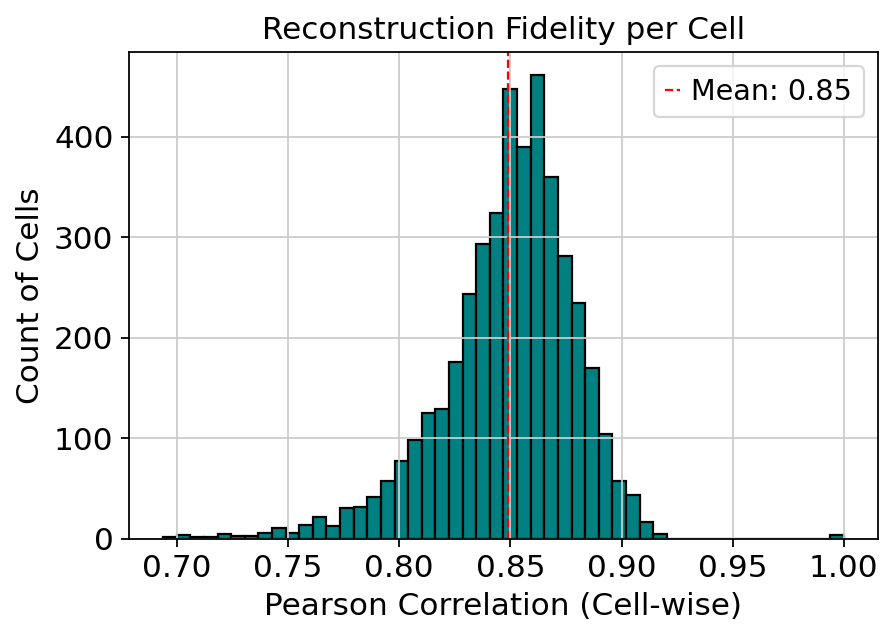

In [ ]:
from scipy.stats import pearsonr

correlations = []
n_cells = pred_adata.shape[0]

# Convert to dense once if memory allows, or iterate carefully
X_gt = real_adata.X if not hasattr(real_adata.X, "toarray") else real_adata.X.toarray()
X_model = pred_adata.X if not hasattr(pred_adata.X, "toarray") else pred_adata.X.toarray()

for i in range(n_cells):
    # Calculate correlation for cell i
    corr, _ = pearsonr(X_gt[i], X_model[i])
    correlations.append(corr)

# Plot Histogram of Correlations
plt.figure(figsize=(6, 4))
plt.hist(correlations, bins=50, color='teal', edgecolor='black')
plt.xlabel("Pearson Correlation (Cell-wise)")
plt.ylabel("Count of Cells")
plt.title("Reconstruction Fidelity per Cell")
plt.axvline(np.mean(correlations), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(correlations):.2f}')
plt.legend()
plt.show()

***

### **Generative model - please work**

In [ ]:
def generate_adata(perts_x_ncells, model, gene_to_idx, var_names):
    prediction_list = []
    obs_gene_list = []

    # for each perturbation....
    for pert in perts_x_ncells.keys():
        if pert != "non-targeting":
            print(pert)

            # how many cells are in the real data and I have to generate with the generative model?
            n_cells = perts_x_ncells[pert]

            # index corresponding to the pert
            ko_gene_idx = gene_to_idx[pert]

            # generate n_cell perturbed cells
            for j in range(n_cells):
                _, predicted_full_gex = model.generative_prediction(ko_gene_idx)
                predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
                prediction_list.append(predicted_full_gex.numpy()) 
                obs_gene_list.append(pert)

    # Stack all (1, N) vectors → shape (total_cells, N)
    X = np.vstack(prediction_list)

    # Build obs dataframe
    obs = pd.DataFrame({
        "target_gene": obs_gene_list
    })

    # Build var dataframe (gene names)
    var = pd.DataFrame(index=var_names)   # length N list of gene names

    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    return pred_adata

In [ ]:
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 200]

# Remove 'non-targeting'
gene_counts_dict = counts.drop('non-targeting').to_dict()
del counts

pred_adata2 = generate_adata(gene_counts_dict, model, gene_to_idx, real_adata.var_names)
pred_adata2


***

### Other analysis

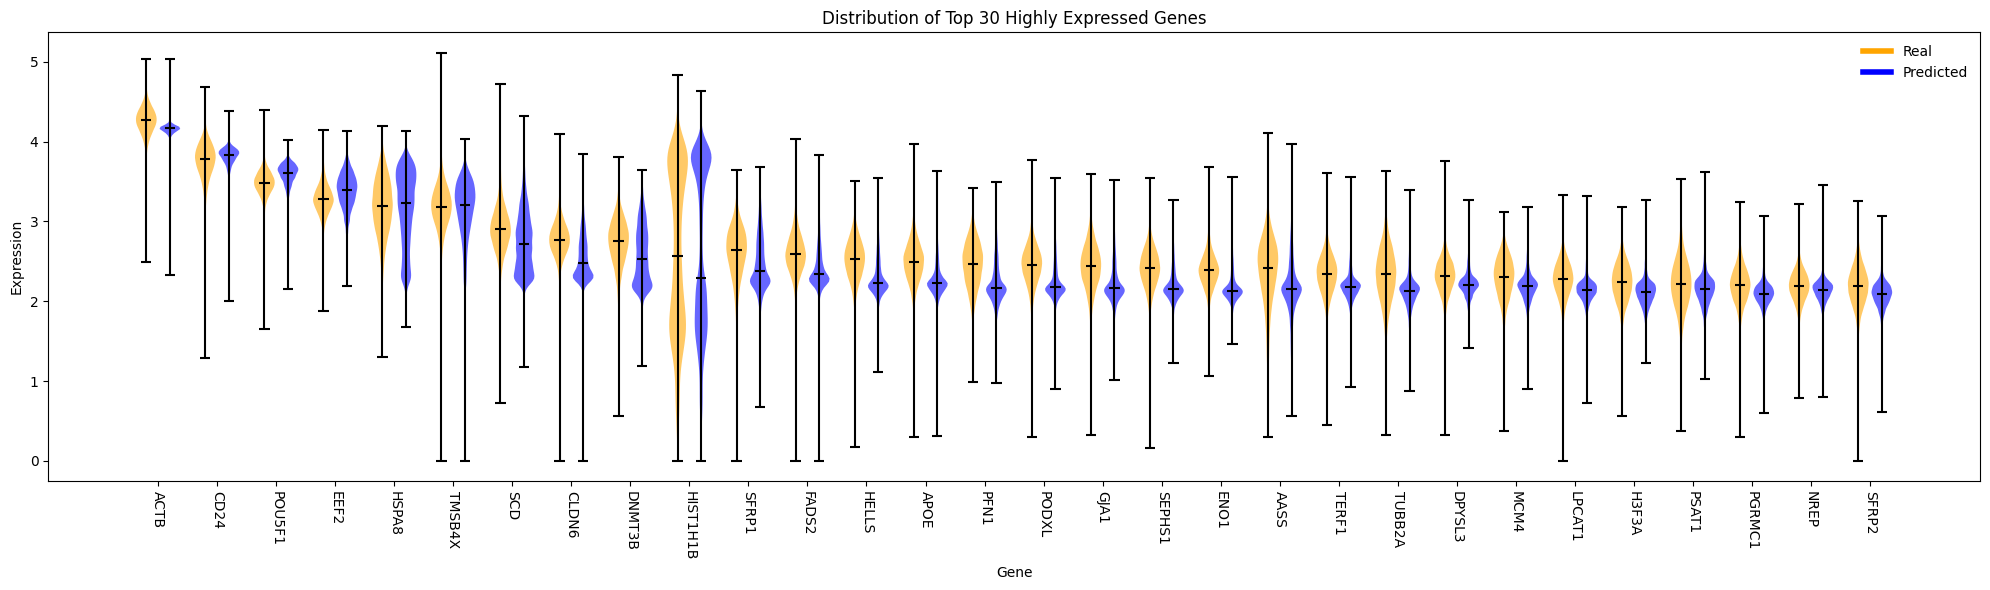

In [38]:
from visualization import plot_top_highly_expressed_genes
from visualization import plot_top_highly_variable_genes

plot_top_highly_expressed_genes(30, real_adata, pred_adata, False)

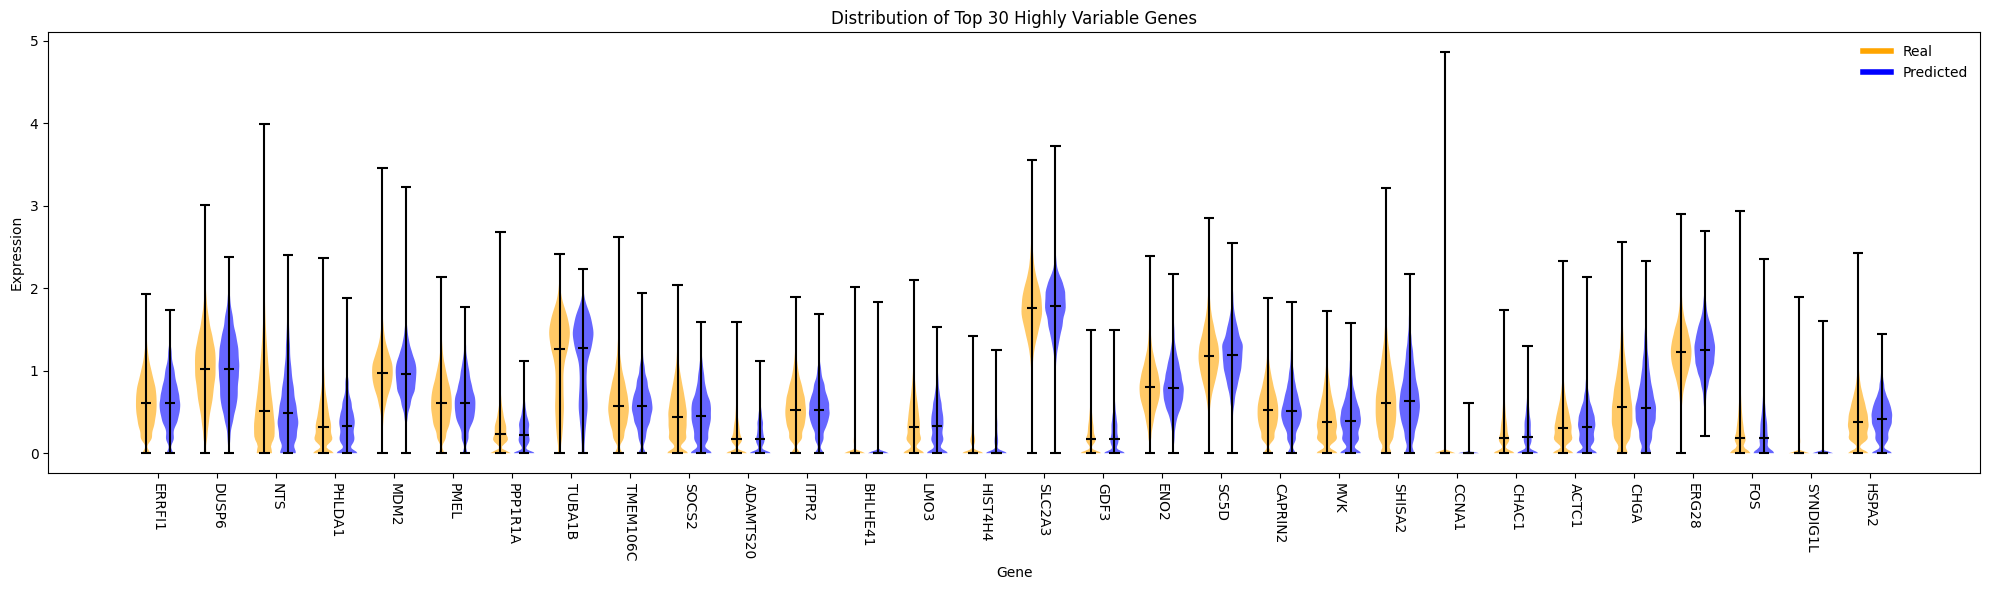

In [39]:
plot_top_highly_variable_genes(30, real_adata, pred_adata, False)

**let's try with just the DE genes**

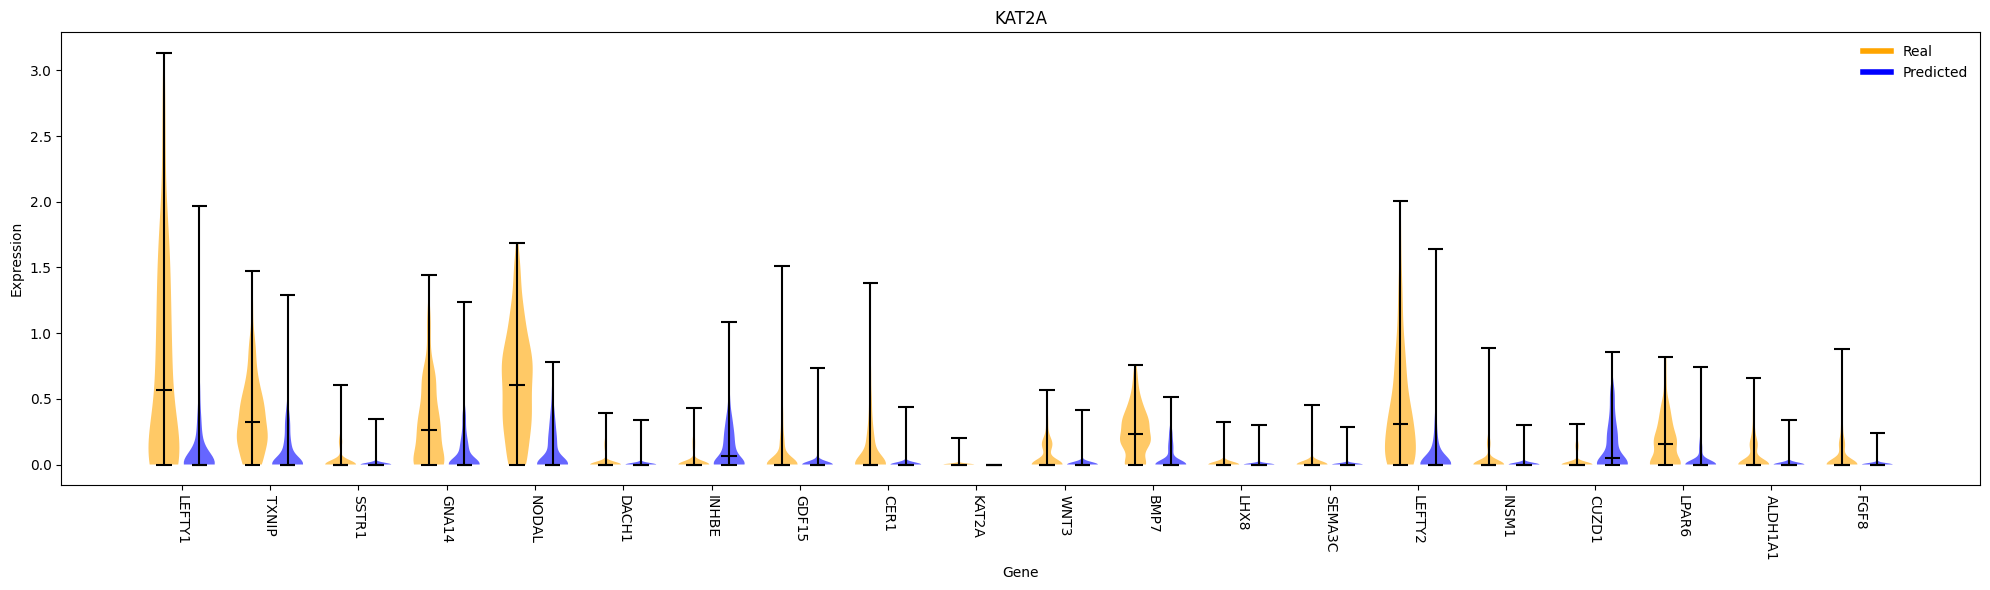

In [40]:
from scores import RobustDES
from visualization import plot_violins_redictions_selected_genes


des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

max_de_genes = 20
perturb_label = 'KAT2A'
DE_genes, _ = des_calculator.get_de_genes(real_adata, 'target_gene', perturb_label, 'non-targeting')
list_DE_genes = list(set(DE_genes.index))
if len(list_DE_genes)>max_de_genes:
    list_DE_genes = list(set(DE_genes.loc[DE_genes['logfoldchanges'].abs().sort_values(ascending=False).index[:max_de_genes]].index))

plot_violins_redictions_selected_genes(list_DE_genes, 
    real_adata[real_adata.obs['target_gene']==perturb_label], 
    pred_adata[pred_adata.obs['target_gene']==perturb_label], 
    False, 
    perturb_label
)


In [43]:
import seaborn as sns
from scipy.stats import wasserstein_distance, pearsonr
from sklearn.metrics import r2_score

In [44]:
def plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, 
                         target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Plots a scatter plot of Real vs Predicted Log2 Fold Changes for DE genes across multiple perturbations.
    """
    all_real_lfcs = []
    all_pred_lfcs = []
    
    # Get the real control cells to serve as the baseline for predicted LFC
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        # 1. Get Real DE genes and their Real LFCs
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        real_lfc = de_df['logfoldchanges'].values
        
        # 2. Calculate Predicted LFCs for these specific DE genes
        pred_perturb_adata = pred_adata[pred_adata.obs[target_col] == perturb]
        
        # Extract matrices
        pred_X = pred_perturb_adata[:, de_genes].X
        ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(pred_X, "toarray"): pred_X = pred_X.toarray()
        if hasattr(ctrl_X, "toarray"): ctrl_X = ctrl_X.toarray()
            
        # Means per gene (add small pseudocount to avoid log(0))
        mean_pred = pred_X.mean(axis=0) + 1e-9
        mean_ctrl = ctrl_X.mean(axis=0) + 1e-9
        
        # Log2 fold change: log2(Predicted Perturb / Real Control)
        pred_lfc = np.log2(mean_pred / mean_ctrl)
        
        all_real_lfcs.extend(real_lfc)
        all_pred_lfcs.extend(pred_lfc)
        
    # Calculate global Pearson correlation
    r_val, p_val = pearsonr(all_real_lfcs, all_pred_lfcs)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.scatterplot(x=all_real_lfcs, y=all_pred_lfcs, alpha=0.5, s=10, edgecolor=None, color='#1f77b4', ax=ax)
    
    # Plot identity line (y = x)
    min_val = min(min(all_real_lfcs), min(all_pred_lfcs))
    max_val = max(max(all_real_lfcs), max(all_pred_lfcs))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=0.5, label='Perfect Prediction (y=x)')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Ground Truth LFC (Real Perturbed vs Real Control)')
    ax.set_ylabel('Predicted LFC (Pred Perturbed vs Real Control)')
    ax.set_title(f'Global LFC Correlation\nPearson R = {r_val:.3f} (p={p_val:.2e})')
    ax.legend(frameon=False)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('LFC_Correlation_Plot.pdf')
    plt.show()

In [45]:
def plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, 
                               target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the average Wasserstein distance of DE genes between real and predicted cells for each perturbation.
    """
    perturb_distances = {}
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate the cells for this specific perturbation
        real_vals = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_vals = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        
        if hasattr(real_vals, "toarray"): real_vals = real_vals.toarray()
        if hasattr(pred_vals, "toarray"): pred_vals = pred_vals.toarray()
            
        # Calculate Wasserstein distance for each gene independently
        w_dists = [wasserstein_distance(real_vals[:, i], pred_vals[:, i]) for i in range(len(de_genes))]
        
        # Store the average distance for this perturbation
        perturb_distances[perturb] = np.mean(w_dists)
        
    # Convert to DataFrame for easy Seaborn plotting and sorting
    df_dists = pd.DataFrame(list(perturb_distances.items()), columns=['Perturbation', 'Avg_Wasserstein_Distance'])
    df_dists = df_dists.sort_values('Avg_Wasserstein_Distance', ascending=False) # Highest distance = worst prediction
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_dists, x='Perturbation', y='Avg_Wasserstein_Distance', color='salmon', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('Average Wasserstein Distance (Lower is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('Distribution Match between Real and Predicted Perturbations')
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Wasserstein_Distances.pdf')
    plt.show()

In [46]:
def plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, 
                       target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the R-squared score between the real and predicted *change in mean expression* (Delta) of DE genes relative to the control state.
    """
    perturb_r2 = {}
    
    # Baseline: Real control cells
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        
        # R2 score requires at least 2 genes to compute variance.
        if de_df.empty or len(de_df) < 2:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate matrices
        real_perturb_X = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_perturb_X = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        real_ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(real_perturb_X, "toarray"): real_perturb_X = real_perturb_X.toarray()
        if hasattr(pred_perturb_X, "toarray"): pred_perturb_X = pred_perturb_X.toarray()
        if hasattr(real_ctrl_X, "toarray"): real_ctrl_X = real_ctrl_X.toarray()
        
        # Calculate means
        real_perturb_means = real_perturb_X.mean(axis=0)
        pred_perturb_means = pred_perturb_X.mean(axis=0)
        real_ctrl_means = real_ctrl_X.mean(axis=0)
        
        # CALCULATE DELTAS (Effect Size)
        real_delta = real_perturb_means - real_ctrl_means
        pred_delta = pred_perturb_means - real_ctrl_means
        
        # Calculate R-squared score on the deltas
        r2 = r2_score(real_delta, pred_delta)
        perturb_r2[perturb] = r2
        
    # Convert to DataFrame
    df_r2 = pd.DataFrame(list(perturb_r2.items()), columns=['Perturbation', 'R2_Score_of_Delta'])
    df_r2 = df_r2.sort_values('R2_Score_of_Delta', ascending=False)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_r2, x='Perturbation', y='R2_Score_of_Delta', color='mediumseagreen', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('$R^2$ Score of Delta (Higher is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('$R^2$ of Perturbation Effect (Delta) per Perturbation')
    ax.axhline(0, color='black', lw=1) # Baseline at 0 (worse than 0 means predicting the mean delta is better)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Delta_R2_Scores.pdf')
    plt.show()

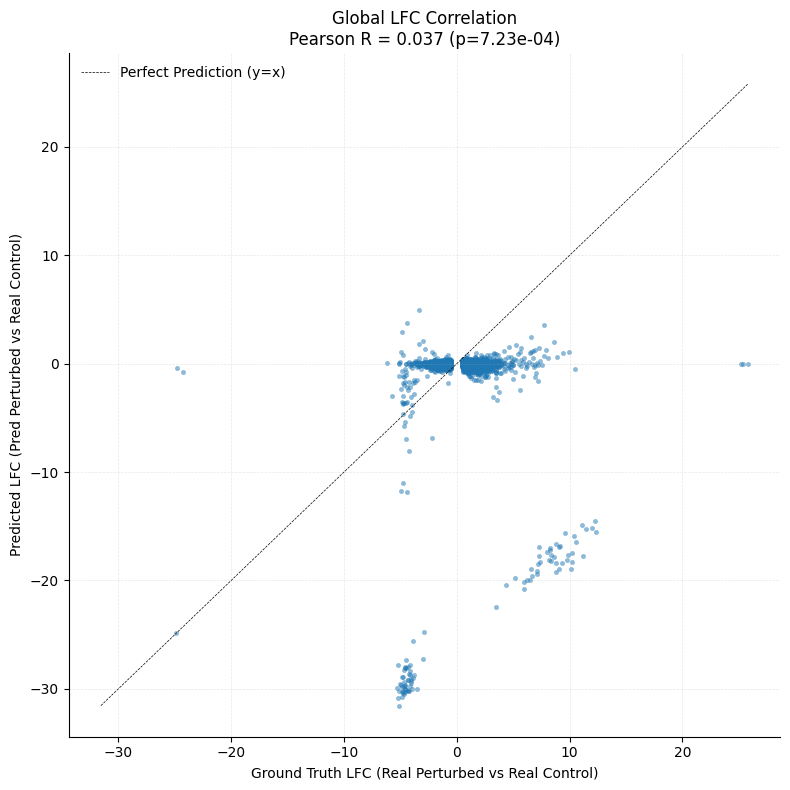

In [47]:
# Remove the control label from your perturbation list so we don't calculate DE for control vs control
perturb_list = [p for p in real_adata.obs['target_gene'].unique() if p != 'non-targeting']

# Option A: Plot Global LFC Scatter
plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, save=False)


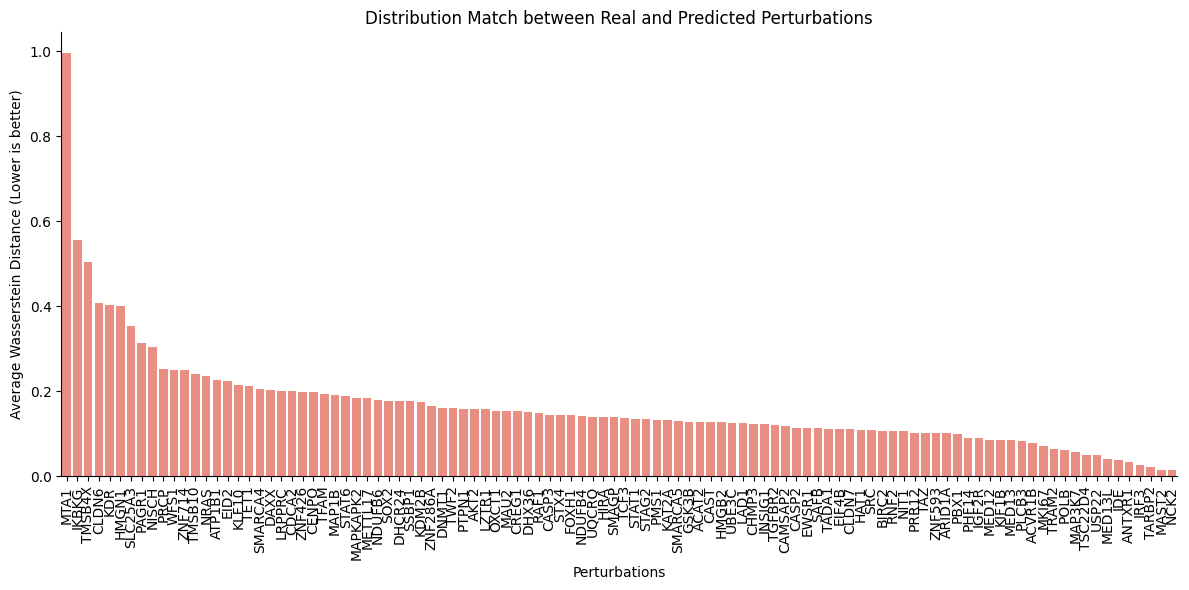

In [48]:

# Option B: Plot Wasserstein Distance Bar Chart
plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, save=False)


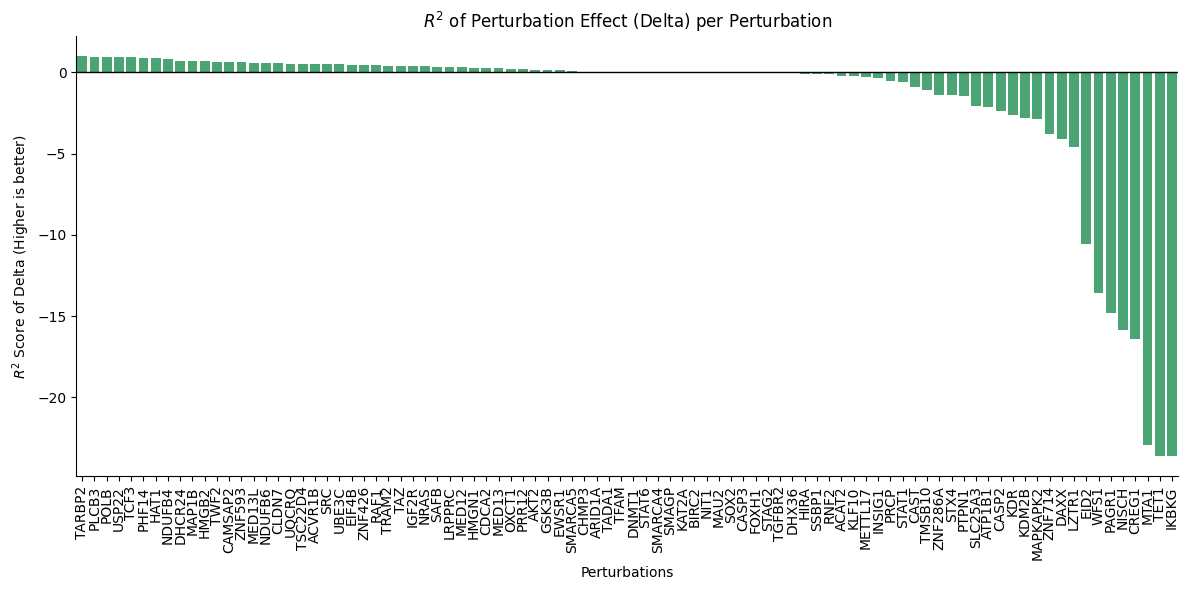

In [49]:
# Option C: Plot R2 Bar Chart
plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, save=False)